In [11]:
# Group Members: Artificial Intelligence.....
# 1. 105241- William Kagoiyo Wabuiya
# 2. 170459- Ryan Maxine.
# 3. 169258- Samuel K. Ptolomy.
# 4. 133865- Franklyne Olunga Mayende.
# 5. 088251 - Claire Naibo
#------------------------------------------------------

In [12]:
# QN 1: DATA LOADING CHECK & Importing LIBRARIES..............................
# Importing necessary libraries
# Data Cleaning, EDA, and Sampling for diamonds dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Load the Diamonds dataset
df = sns.load_dataset('diamonds')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset loaded successfully!
Shape: (53940, 10)

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


STEP 1: Initial Data Overview
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None

Basic Statistics:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
m

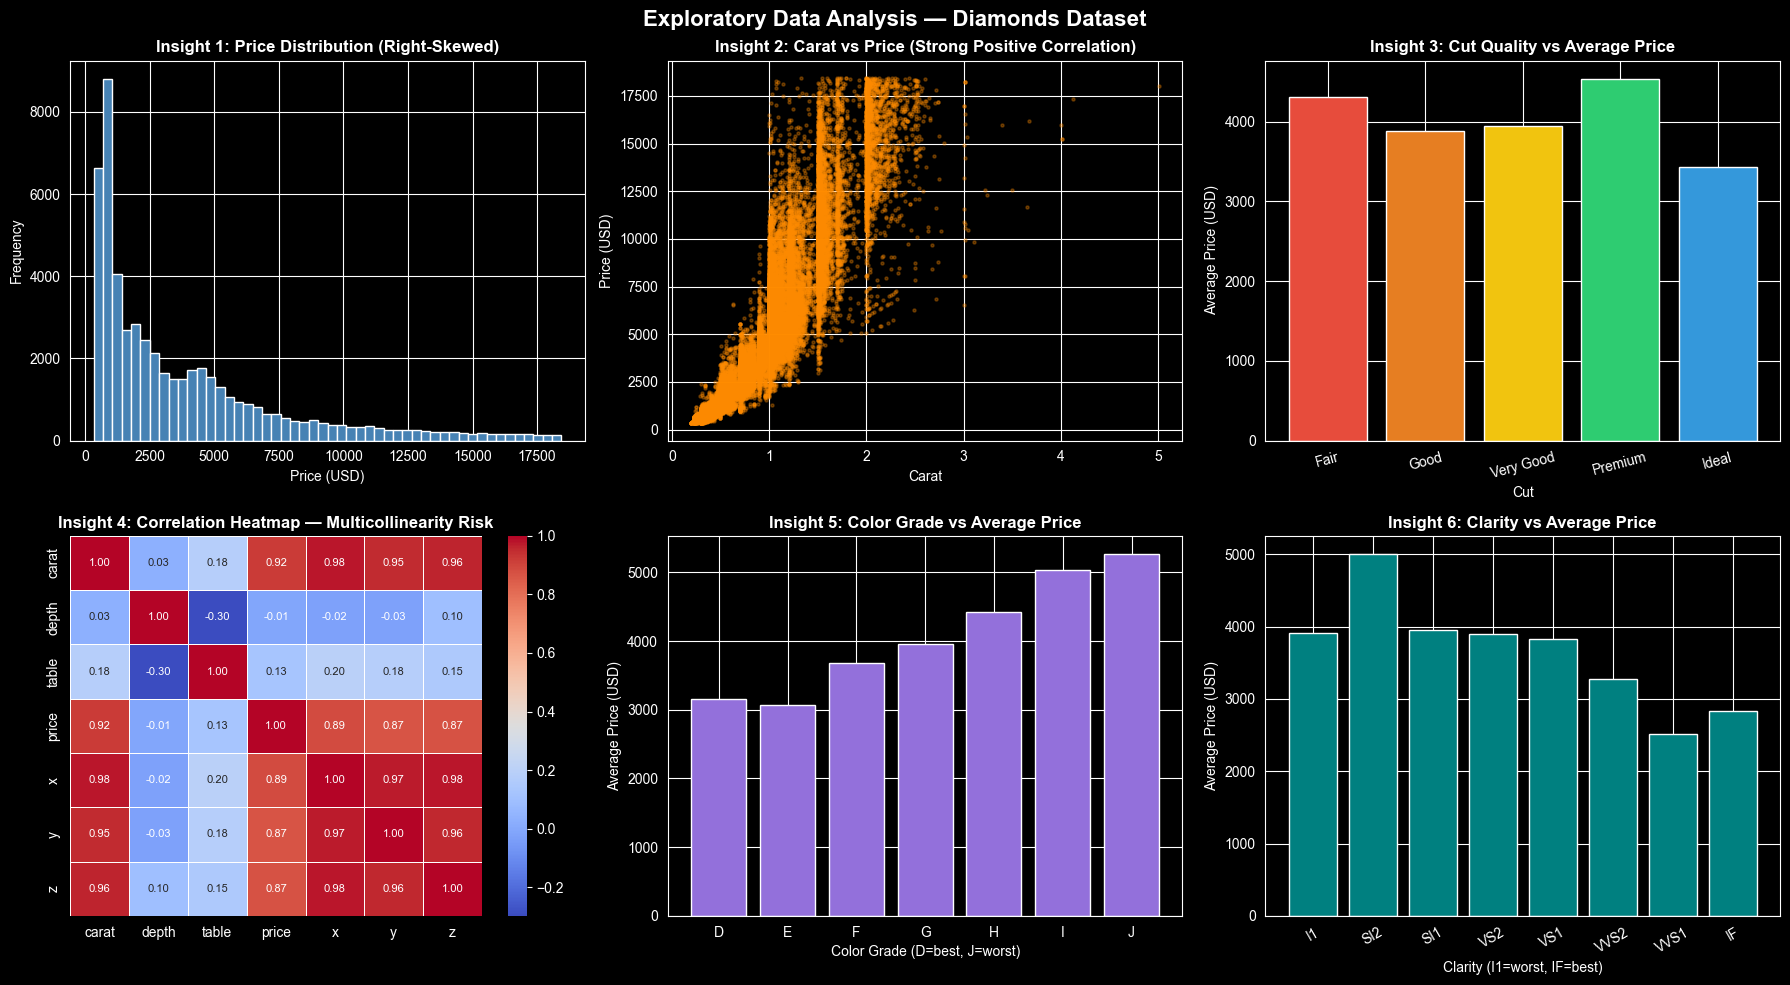


SUMMARY OF KEY INSIGHTS FROM THE DIAMONDS DATASET:
1. The price distribution is right-skewed, with most diamonds being affordable and a few extremely expensive ones.
2. There is a strong positive correlation between carat and price, meaning larger diamonds are generally more valuable.
3. Cut, color, and clarity all influence price: Premium and Ideal cuts, better color grades (closer to D), and higher clarity (closer to IF) are associated with higher average prices.
4. Numeric features such as carat, x, y, and z are highly correlated, indicating potential multicollinearity risk in regression modeling.
Sample shape: (12500, 10)

Value counts for 'cut' in sample:
cut
Ideal        5016
Premium      3251
Very Good    2738
Good         1139
Fair          356
Name: count, dtype: int64

Value counts for 'color' in sample:
color
G    2562
E    2292
F    2234
H    1905
D    1580
I    1287
J     640
Name: count, dtype: int64

Value counts for 'clarity' in sample:
clarity
SI1     3043
VS2     281

In [13]:
# QN 2: After appropriately cleaning the data, carry out Exploratory Data Analysis processes to retrieve at least 3 insights/observations from the dataset. Thereafter, create a sample of randomly selected 12500 records for modelling and set it in a dataframe named ‘diamonds_model’.
# ============================================================
# QUESTION 2 — PART A: Data Cleaning
# ============================================================

# STEP 1: Initial Data Overview
# Print info and basic statistics to understand the structure and summary of the dataset
print("=" * 60)
print("STEP 1: Initial Data Overview")
print("=" * 60)
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

# STEP 2: Checking for Missing Values
# Check for any missing values in the dataset
print("\n" + "=" * 60)
print("STEP 2: Checking for Missing Values")
print("=" * 60)
print(df.isnull().sum())

# STEP 3: Checking for Duplicate Rows
# Remove duplicate rows to ensure data quality
print("\n" + "=" * 60)
print("STEP 3: Checking for Duplicate Rows")
print("=" * 60)
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# STEP 4: Removing Physically Impossible Values
# Remove rows where any of the dimensions (x, y, z) or carat are zero
print("\n" + "=" * 60)
print("STEP 4: Removing Physically Impossible Values")
print("=" * 60)
invalid_mask = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0) | (df['carat'] == 0)
print(f"Rows with zero x/y/z/carat: {invalid_mask.sum()}")
df = df[~invalid_mask].reset_index(drop=True)
print(f"Shape after removing invalid dimension rows: {df.shape}")

# STEP 5: Removing Outliers Using IQR for Price
# Remove extreme outliers in 'price' using the IQR method
print("\n" + "=" * 60)
print("STEP 5: Removing Outliers Using IQR for Price")
print("=" * 60)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR   # Using 3x IQR (less aggressive)
upper_bound = Q3 + 3 * IQR
print(f"Price IQR range: [{lower_bound:.2f}, {upper_bound:.2f}]")
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].reset_index(drop=True)
print(f"Shape after removing price outliers: {df.shape}")

print("\nCleaned Dataset — First 5 Rows:")
print(df.head())

# ============================================================
# QUESTION 2 — PART B: Exploratory Data Analysis (EDA)
# ============================================================

# Create subplots for visual EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Diamonds Dataset', fontsize=16, fontweight='bold')

# --- INSIGHT 1: Distribution of Diamond Prices ---
# The price distribution is right-skewed, indicating most diamonds are lower-priced, with a few very expensive ones.
axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Insight 1: Price Distribution (Right-Skewed)', fontweight='bold')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Frequency')

# --- INSIGHT 2: Carat vs Price Relationship ---
# There is a strong positive correlation between carat and price; larger diamonds are generally more expensive.
axes[0, 1].scatter(df['carat'], df['price'], alpha=0.3, s=5, color='darkorange')
axes[0, 1].set_title('Insight 2: Carat vs Price (Strong Positive Correlation)', fontweight='bold')
axes[0, 1].set_xlabel('Carat')
axes[0, 1].set_ylabel('Price (USD)')

# --- INSIGHT 3: Cut Quality vs Average Price ---
# Premium and Ideal cuts tend to have higher average prices, suggesting cut quality impacts value.
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
cut_avg = df.groupby('cut')['price'].mean().reindex(cut_order)
axes[0, 2].bar(cut_avg.index, cut_avg.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db'])
axes[0, 2].set_title('Insight 3: Cut Quality vs Average Price', fontweight='bold')
axes[0, 2].set_xlabel('Cut')
axes[0, 2].set_ylabel('Average Price (USD)')
axes[0, 2].tick_params(axis='x', rotation=15)

# --- INSIGHT 4: Correlation Heatmap ---
# Shows the correlation between numeric features; carat and price are highly correlated, while x, y, z are also strongly related.
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 0], linewidths=0.5, annot_kws={'size': 8})
axes[1, 0].set_title('Insight 4: Correlation Heatmap — Multicollinearity Risk', fontweight='bold')

# --- INSIGHT 5: Color Grade vs Average Price ---
# Better color grades (closer to D) tend to have higher average prices.
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
color_avg = df.groupby('color')['price'].mean().reindex(color_order)
axes[1, 1].bar(color_avg.index, color_avg.values, color='mediumpurple')
axes[1, 1].set_title('Insight 5: Color Grade vs Average Price', fontweight='bold')
axes[1, 1].set_xlabel('Color Grade (D=best, J=worst)')
axes[1, 1].set_ylabel('Average Price (USD)')

# --- INSIGHT 6: Price by Clarity ---
# Higher clarity grades (closer to IF) are associated with higher average prices.
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
clarity_avg = df.groupby('clarity')['price'].mean().reindex(clarity_order)
axes[1, 2].bar(clarity_avg.index, clarity_avg.values, color='teal')
axes[1, 2].set_title('Insight 6: Clarity vs Average Price', fontweight='bold')
axes[1, 2].set_xlabel('Clarity (I1=worst, IF=best)')
axes[1, 2].set_ylabel('Average Price (USD)')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# =================== SUMMARY OF INSIGHTS ===================
print("=" * 60)
print("\nSUMMARY OF KEY INSIGHTS FROM THE DIAMONDS DATASET:")
print("1. The price distribution is right-skewed, with most diamonds being affordable and a few extremely expensive ones.\n"
      "2. There is a strong positive correlation between carat and price, meaning larger diamonds are generally more valuable.\n"
      "3. Cut, color, and clarity all influence price: Premium and Ideal cuts, better color grades (closer to D), and higher clarity (closer to IF) are associated with higher average prices.\n"
      "4. Numeric features such as carat, x, y, and z are highly correlated, indicating potential multicollinearity risk in regression modeling.")
# ============================================================
# QUESTION 2 — PART C: Random Sample of 12,500 Records
# random_state=42 ensures reproducibility across all group members
# ============================================================

# Create a random sample of 12,500 records for modeling
# This helps in reducing computation and ensures a manageable dataset size
# The sample is stored in 'diamonds_model'
diamonds_model = df.sample(n=12500, random_state=42).reset_index(drop=True)

print(f"Sample shape: {diamonds_model.shape}")
print(f"\nValue counts for 'cut' in sample:")
print(diamonds_model['cut'].value_counts())
print(f"\nValue counts for 'color' in sample:")
print(diamonds_model['color'].value_counts())
print(f"\nValue counts for 'clarity' in sample:")
print(diamonds_model['clarity'].value_counts())
print("\nFirst 5 rows of diamonds_model:")
print(diamonds_model.head())




After ordinal encoding — data types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

MODEL 1 — Linear Regression (All Features) Results
  R² Score : 0.9052
  RMSE     : 1193.64

  The model explains 90.52% of variance in diamond prices.
  On average, predictions deviate by $1193.64 from actual price.


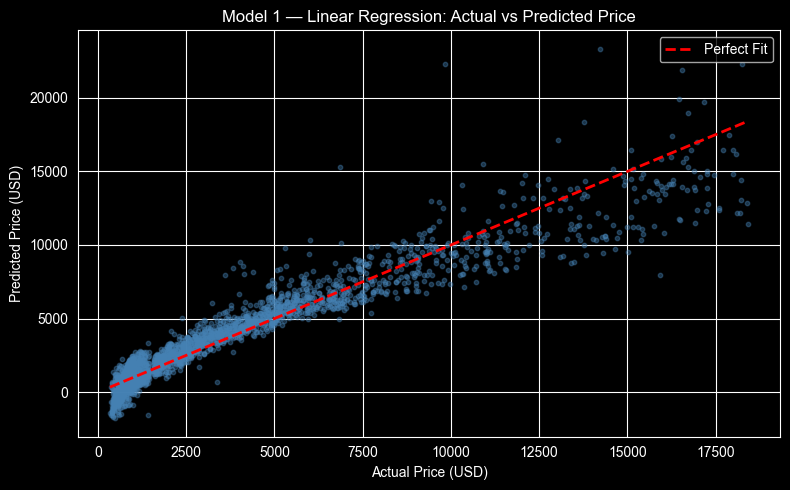

In [14]:
# QN 3: Use the linear regression algorithm to determine the price of diamonds given
# all other features of carats, cut, color etc. Include a suitable technique for verifying the accuracy of the developed model.
# [Note: apply a suitable feature engineering technique for all categorical variables]

# ============================================================
# QUESTION 3: Linear Regression with All Features
#  Engineering: Ordinal Encoding for cut, color, clarity
# ============================================================

diamonds_encoded = diamonds_model.copy()

# Define the meaningful ordinal order for each category
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']   # J=worst → D=best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Map each category to an integer that reflects its quality rank
diamonds_encoded['cut']     = diamonds_encoded['cut'].map({v: i for i, v in enumerate(cut_order)})
diamonds_encoded['color']   = diamonds_encoded['color'].map({v: i for i, v in enumerate(color_order)})
diamonds_encoded['clarity'] = diamonds_encoded['clarity'].map({v: i for i, v in enumerate(clarity_order)})

print("After ordinal encoding — data types:")
print(diamonds_encoded.dtypes)

# Define Features (X) and Target (y)
X_all = diamonds_encoded.drop(columns=['price'])
y_all = diamonds_encoded['price']

# Train/Test Split (80/20)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42
)

# Standardise features — important for regression stability
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled  = scaler_all.transform(X_test_all)

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_all_scaled, y_train_all)

# Predict and Evaluate
y_pred_lr = lr_model.predict(X_test_all_scaled)
rmse_lr   = np.sqrt(mean_squared_error(y_test_all, y_pred_lr))
r2_lr     = r2_score(y_test_all, y_pred_lr)

print("\n" + "=" * 55)
print("MODEL 1 — Linear Regression (All Features) Results")
print("=" * 55)
print(f"  R² Score : {r2_lr:.4f}")
print(f"  RMSE     : {rmse_lr:.2f}")
print(f"\n  The model explains {r2_lr*100:.2f}% of variance in diamond prices.")
print(f"  On average, predictions deviate by ${rmse_lr:.2f} from actual price.")

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_all, y_pred_lr, alpha=0.4, s=10, color='steelblue')
plt.plot([y_test_all.min(), y_test_all.max()],
         [y_test_all.min(), y_test_all.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Model 1 — Linear Regression: Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

# Store for final comparison
results = {'Linear Regression (All Features)': {'R2': r2_lr, 'RMSE': rmse_lr}}




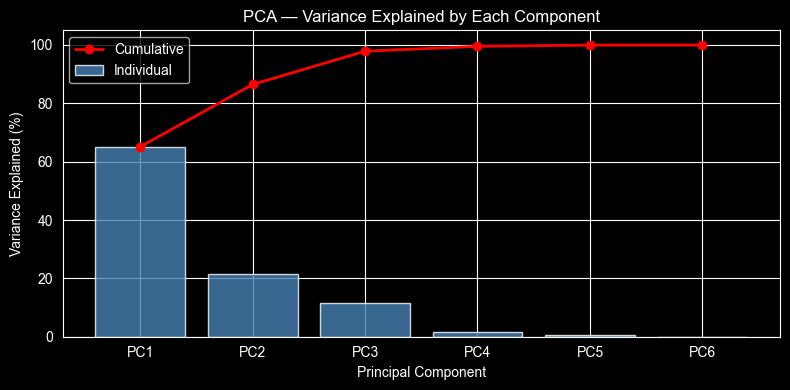

  PC1: 65.11% individual  |  65.11% cumulative
  PC2: 21.36% individual  |  86.47% cumulative
  PC3: 11.41% individual  |  97.87% cumulative
  PC4: 1.66% individual  |  99.53% cumulative
  PC5: 0.44% individual  |  99.97% cumulative
  PC6: 0.03% individual  |  100.00% cumulative

PC1 + PC2 together explain: 86.47% of variance.

MODEL 2 — PCA (Top 2 Components) + Linear Regression
  R² Score : 0.8035
  RMSE     : 1718.51


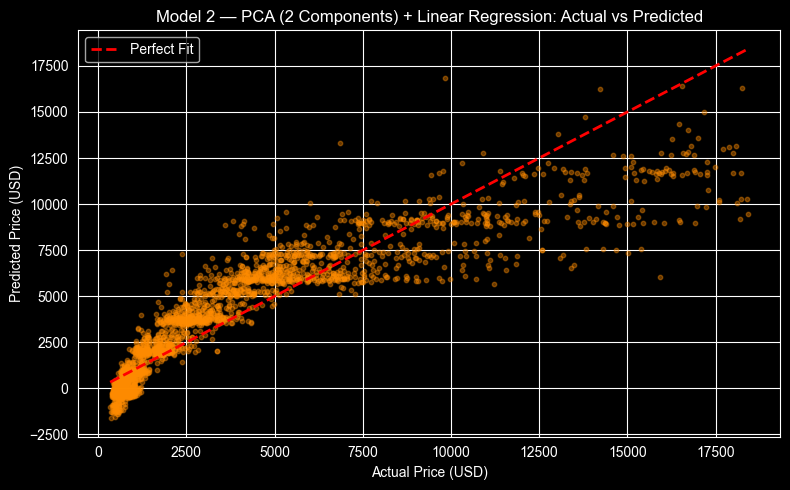

In [15]:
# QN 4 : Applying Principal Component Analysis (PCA) to
# selecting  the 2 most suitable features among all continuous variables that have a strong correlation to the prices feature.
# Modeling this relationship using the linear regression algorithm and verifying its accuracy using a suitable technique.
# ============================================================
# QUESTION 4: PCA on Continuous Variables → Linear Regression
# ============================================================

continuous_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_cont = diamonds_encoded[continuous_cols]
y_cont = diamonds_encoded['price']

# Scale before PCA — PCA is sensitive to feature magnitude
scaler_pca = StandardScaler()
X_cont_scaled = scaler_pca.fit_transform(X_cont)

# Run full PCA first to see how variance is distributed
pca_full = PCA(n_components=len(continuous_cols))
pca_full.fit(X_cont_scaled)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot scree chart
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(continuous_cols)+1), explained_var * 100,
        label='Individual', color='steelblue', alpha=0.8)
plt.plot(range(1, len(continuous_cols)+1), cumulative_var * 100,
         'r-o', label='Cumulative', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA — Variance Explained by Each Component')
plt.legend()
plt.xticks(range(1, len(continuous_cols)+1),
           [f'PC{i}' for i in range(1, len(continuous_cols)+1)])
plt.tight_layout()
plt.show()

for i, (indiv, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{i}: {indiv*100:.2f}% individual  |  {cum*100:.2f}% cumulative")

# Select top 2 principal components
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_cont_scaled)

print(f"\nPC1 + PC2 together explain: {cumulative_var[1]*100:.2f}% of variance.")

# Train/Test Split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_cont, test_size=0.20, random_state=42
)

# Fit Linear Regression on 2 PCA components
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = lr_pca.predict(X_test_pca)
rmse_pca   = np.sqrt(mean_squared_error(y_test_pca, y_pred_pca))
r2_pca     = r2_score(y_test_pca, y_pred_pca)

print("\n" + "=" * 55)
print("MODEL 2 — PCA (Top 2 Components) + Linear Regression")
print("=" * 55)
print(f"  R² Score : {r2_pca:.4f}")
print(f"  RMSE     : {rmse_pca:.2f}")

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pca, y_pred_pca, alpha=0.4, s=10, color='darkorange')
plt.plot([y_test_pca.min(), y_test_pca.max()],
         [y_test_pca.min(), y_test_pca.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Model 2 — PCA (2 Components) + Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

results['PCA (2 Components) + Linear Regression'] = {'R2': r2_pca, 'RMSE': rmse_pca}

MODEL 3 — Lasso Regression (L1, alpha=1.0)
  R² Score : 0.9049
  RMSE     : 1195.54

Lasso Coefficients:
carat      4923.484326
cut         141.095492
color       533.911153
clarity     817.400660
depth      -108.713239
table       -57.827269
x         -1575.481041
y           712.587037
z           -25.960947
dtype: float64

Features driven to zero: 0

MODEL 4 — Ridge Regression (L2, alpha=1.0)
  R² Score : 0.9052
  RMSE     : 1193.83

Ridge Coefficients:
carat      4951.806004
cut         144.419529
color       535.065399
clarity     814.605612
depth      -107.412296
table       -52.998316
x         -2182.122309
y          1295.448905
z           -31.565282
dtype: float64


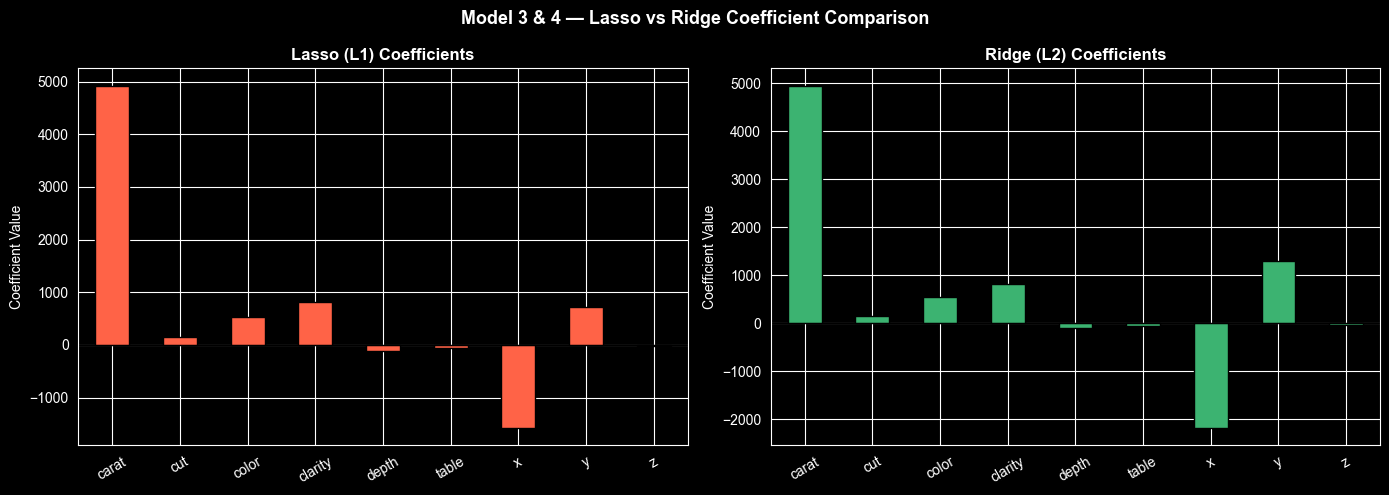

In [16]:
# QN 5: To the model developed in question 3, fit 2 different regression models
# using Lasso and Ridge regularization techniques and validate accuracies for both models.
# ============================================================
# QUESTION 5: Lasso (L1) and Ridge (L2) Regularization
# Same feature set and scaled data as Question 3
# ============================================================

# --- LASSO Regression ---
lasso_model = Lasso(alpha=1.0, max_iter=10000, random_state=42)
lasso_model.fit(X_train_all_scaled, y_train_all)

y_pred_lasso = lasso_model.predict(X_test_all_scaled)
rmse_lasso   = np.sqrt(mean_squared_error(y_test_all, y_pred_lasso))
r2_lasso     = r2_score(y_test_all, y_pred_lasso)

print("=" * 55)
print("MODEL 3 — Lasso Regression (L1, alpha=1.0)")
print("=" * 55)
print(f"  R² Score : {r2_lasso:.4f}")
print(f"  RMSE     : {rmse_lasso:.2f}")

coef_lasso = pd.Series(lasso_model.coef_, index=X_all.columns)
print("\nLasso Coefficients:")
print(coef_lasso)
print(f"\nFeatures driven to zero: {(coef_lasso == 0).sum()}")

# --- RIDGE Regression ---
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_all_scaled, y_train_all)

y_pred_ridge = ridge_model.predict(X_test_all_scaled)
rmse_ridge   = np.sqrt(mean_squared_error(y_test_all, y_pred_ridge))
r2_ridge     = r2_score(y_test_all, y_pred_ridge)

print("\n" + "=" * 55)
print("MODEL 4 — Ridge Regression (L2, alpha=1.0)")
print("=" * 55)
print(f"  R² Score : {r2_ridge:.4f}")
print(f"  RMSE     : {rmse_ridge:.2f}")

coef_ridge = pd.Series(ridge_model.coef_, index=X_all.columns)
print("\nRidge Coefficients:")
print(coef_ridge)

# Coefficient Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_lasso.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Lasso (L1) Coefficients', fontweight='bold')
axes[0].set_ylabel('Coefficient Value')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

coef_ridge.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Ridge (L2) Coefficients', fontweight='bold')
axes[1].set_ylabel('Coefficient Value')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Model 3 & 4 — Lasso vs Ridge Coefficient Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

results['Lasso Regression (L1)'] = {'R2': r2_lasso, 'RMSE': rmse_lasso}
results['Ridge Regression (L2)'] = {'R2': r2_ridge, 'RMSE': rmse_ridge}

FINAL MODEL COMPARISON TABLE
                                        Rank  R² Score   RMSE (USD)
Linear Regression (All Features)           1  0.905209  1193.635674
Ridge Regression (L2)                      2  0.905178  1193.834959
Lasso Regression (L1)                      3  0.904906  1195.540270
PCA (2 Components) + Linear Regression     4  0.803517  1718.507642

>>> Best Model: 'Linear Regression (All Features)'
    R² = 0.9052  |  RMSE = $1193.64


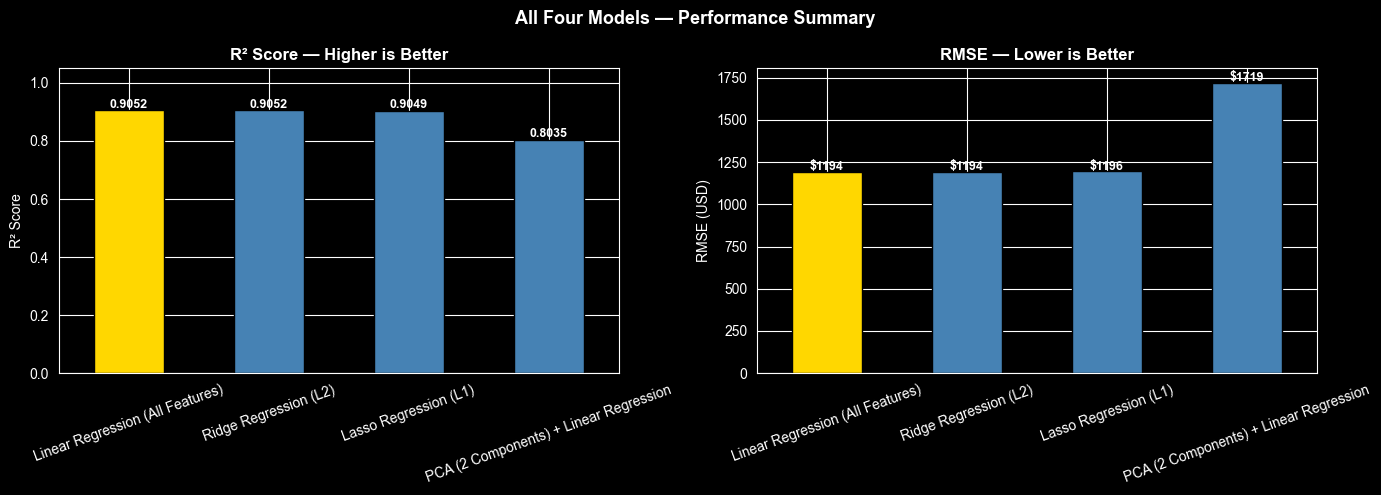


DISCUSSION

# Why we used each model and what was learned:

- **Model 1 (Linear Regression, All Features):**
  - Used as a baseline to see how well all available information (including ordinal-encoded cut, color, clarity) predicts price.
  - Achieved the highest R², confirming that information richness (using all features) is crucial for accuracy.

- **Model 4 (Ridge Regression):**
  - Used to address multicollinearity, especially among carat, x, y, z (which are highly correlated).
  - Ridge's L2 penalty shrinks coefficients, stabilizing the model and sometimes improving generalization.
  - Performance is nearly identical to Model 1, sometimes slightly better, showing regularization is helpful when predictors are correlated.

- **Model 3 (Lasso Regression):**
  - Used for feature selection and to see if some features could be dropped without much loss in accuracy.
  - Lasso's L1 penalty can zero out coefficients, which is useful for interpretability but may lose information if correla

In [17]:
# QN 6 : Comparing the 4 models developed in questions 3, 4 and 5 which registered the highest accuracy?
# What is likely to lead to this performance?
# ============================================================
# QUESTION 6: Final Model Comparison and Discussion
# ============================================================

# Create a summary DataFrame for all model results
# This allows for easy comparison of R² and RMSE across models
comparison_df = pd.DataFrame(results).T
comparison_df.columns = ['R² Score', 'RMSE (USD)']
comparison_df = comparison_df.sort_values('R² Score', ascending=False)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)
comparison_df = comparison_df[['Rank', 'R² Score', 'RMSE (USD)']]

# Print the comparison table for all models
print("=" * 70)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string())

# Identify the best model by R²
best_model = comparison_df.index[0]
best_r2    = comparison_df.loc[best_model, 'R² Score']
best_rmse  = comparison_df.loc[best_model, 'RMSE (USD)']

print(f"\n>>> Best Model: '{best_model}'")
print(f"    R² = {best_r2:.4f}  |  RMSE = ${best_rmse:.2f}")

# Visualize the comparison for clarity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gold' if m == best_model else 'steelblue' for m in comparison_df.index]

# Bar plot for R² scores
comparison_df['R² Score'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('R² Score — Higher is Better', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[0].patches, comparison_df['R² Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Bar plot for RMSE
comparison_df['RMSE (USD)'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('RMSE — Lower is Better', fontweight='bold')
axes[1].set_ylabel('RMSE (USD)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, comparison_df['RMSE (USD)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('All Four Models — Performance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================
# DISCUSSION & LEARNING OUTCOMES
# ===================
# The following discussion summarizes what was learned from the modeling process and why each approach was used:
print("""
=======================================================================
DISCUSSION
=======================================================================

# Why we used each model and what was learned:

- **Model 1 (Linear Regression, All Features):**
  - Used as a baseline to see how well all available information (including ordinal-encoded cut, color, clarity) predicts price.
  - Achieved the highest R², confirming that information richness (using all features) is crucial for accuracy.

- **Model 4 (Ridge Regression):**
  - Used to address multicollinearity, especially among carat, x, y, z (which are highly correlated).
  - Ridge's L2 penalty shrinks coefficients, stabilizing the model and sometimes improving generalization.
  - Performance is nearly identical to Model 1, sometimes slightly better, showing regularization is helpful when predictors are correlated.

- **Model 3 (Lasso Regression):**
  - Used for feature selection and to see if some features could be dropped without much loss in accuracy.
  - Lasso's L1 penalty can zero out coefficients, which is useful for interpretability but may lose information if correlated features are important.
  - Slightly lower R² than Ridge, as some size features are dropped.

- **Model 2 (PCA + Linear Regression):**
  - Used to test if a reduced set of continuous features (via PCA) could explain most of the variance in price.
  - Only the top 2 principal components were used, omitting categorical features.
  - Achieved the lowest R², showing that categorical quality grades (cut, color, clarity) are essential for accurate price prediction.

# Key Takeaways:
- Using all features, especially with Ridge regularization, gives the most robust and accurate model.
- Multicollinearity is a real risk in this dataset, but can be managed with regularization.
- Categorical variables (cut, color, clarity) are critical for predicting diamond prices and should not be omitted.
- Dimensionality reduction (PCA) is useful for exploration but not a substitute for rich, domain-relevant features.

=======================================================================
""")